# 04. Pytorch Custom Datasets Video Notebook

We've used some datasets with PyTorch before.

But how do you get your own data into PyTorch?

One of the ways to do so is via custom datasets

## Domain libraries

Depending on what you're working on, vision, text,audio, recommendation, you'll want to look into each of the PyTorch library existing data loading funcitons and customizable data loading functions

## 0. Importing PyTorch and setting up device-agnostic code

## 1. Get Data

Our dataset is a subset of the Food101 dataset.

Food101 starts 101 different classes of food and 1000 images per class (750 training, 250 testing).

Our dataset starts with 3 classes of food and only 10% of the images (~75 training, 25 testing).

Why do this?

When starting out ML projects, it's important to try things on a small scale and then increase the scale when necessary.

The whole point is to speed up how fast you can experiment

In [204]:
import requests
import zipfile
from pathlib import Path

# Setup path to a data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download and prepare it
if image_path.is_dir():
    print(f"{image_path} directory already exists")
else:
    print(f"{image_path} doesn't exist, creating one")
    image_path.mkdir(parents=True, exist_ok=True)

# Download pizza, steak and sushi data
with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
    print("Downloading pizza, steak and sushi data")
    f.write(request.content)

# Unzip pizza, steak, sushi data
with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
    zip_ref.extractall(image_path)

data\pizza_steak_sushi directory already exists


## 2. Becoming one with the data (data preparation and exploration)

In [205]:
import os
def walk_through_dir(dir_path):
    """Walks through dir_path returning its contents"""
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [206]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data\pizza_steak_sushi'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi\test'.
There are 0 directories and 25 images in 'data\pizza_steak_sushi\test\pizza'.
There are 0 directories and 19 images in 'data\pizza_steak_sushi\test\steak'.
There are 0 directories and 31 images in 'data\pizza_steak_sushi\test\sushi'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi\train'.
There are 0 directories and 78 images in 'data\pizza_steak_sushi\train\pizza'.
There are 0 directories and 75 images in 'data\pizza_steak_sushi\train\steak'.
There are 0 directories and 72 images in 'data\pizza_steak_sushi\train\sushi'.


In [207]:
# Setup train and testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(WindowsPath('data/pizza_steak_sushi/train'),
 WindowsPath('data/pizza_steak_sushi/test'))

### 2.1 Visualizing an image

Let's write some code to:
1. Get all of the image paths
2. Pick a random image path using Python's random.choice()
3. Get the image class name using `pathlib.Path.parent.stem`
4. Since we're working with images, let's open the image using Python's PIL
5. We'll then show the image and print metadata

data\pizza_steak_sushi\test\sushi\1987407.jpg
sushi
Random image path: data\pizza_steak_sushi\test\sushi\1987407.jpg
Image class: sushi
Image height: 384
Image width: 512


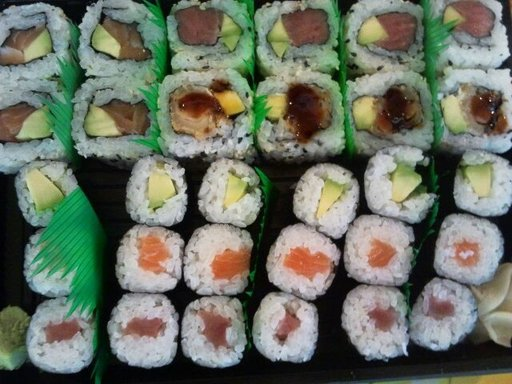

In [208]:
import random
from PIL import Image

# Set seed
# random.seed(42)

# 1. Get all image paths
image_path_list = list(image_path.glob("*/*/*.jpg"))

# 2. Pick a random image path
random_image_path = random.choice(image_path_list)
print(random_image_path)

# 3. Get image class from path name (the image class is the name of the directory where the image is stored)
image_class = random_image_path.parent.stem
print(image_class)

# 4. Open image
img = Image.open(random_image_path)

# 5. Print emtadata
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

(np.float64(-0.5), np.float64(511.5), np.float64(383.5), np.float64(-0.5))

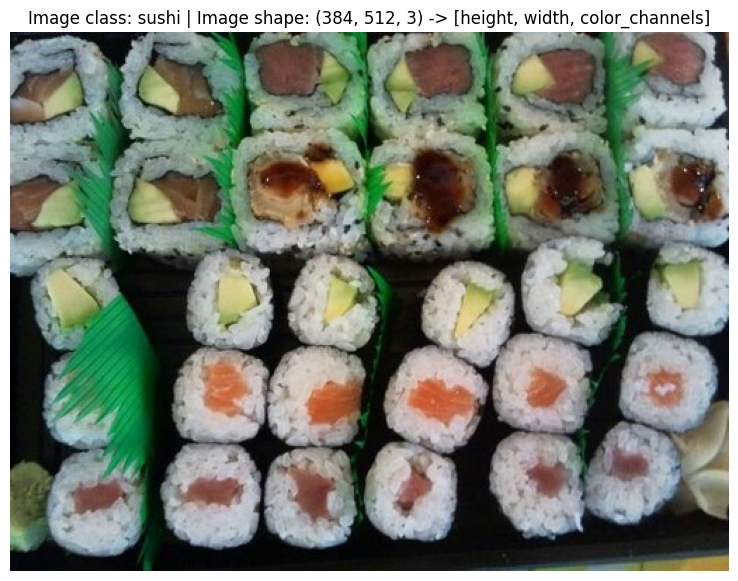

In [209]:
# Try to visualize an image with matplotlib...
import numpy as np
import matplotlib.pyplot as plt

# Turn the image into an array
img_as_array = np.asarray(img)

# Plot the image with matplotlib
plt.figure(figsize=(10,7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape} -> [height, width, color_channels]")
plt.axis(False)

## 3. Transforming data

Before we can use our image data with PyTorch:
1. Turn your target data into tensors (numerical representation of our images)
2. Turn it into a `torch.utils.data.Dataset` and subsequently a `torch.utils.data.Dataloader` we'll call these `Dataset` and `DataLoader`

In [210]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

### 3.1 Transforming data with `torchvision.transforms`

Transforms help you get your images ready to be used with a model/perform data augmentation

In [211]:
# Write a transform for image
data_transform = transforms.Compose([
    # Resize our images to 64x64
    transforms.Resize(size=(64,64)),
    # Flip the images randomly on the horizontal
    transforms.RandomHorizontalFlip(p=0.5),
    # Turn the image into a torch.Tensor
    transforms.ToTensor()
])

In [212]:
data_transform(img)

tensor([[[0.0745, 0.1412, 0.1490,  ..., 0.6706, 0.4431, 0.2157],
         [0.2431, 0.4745, 0.4941,  ..., 0.5843, 0.5608, 0.2078],
         [0.4392, 0.5529, 0.5216,  ..., 0.4588, 0.4941, 0.1647],
         ...,
         [0.2039, 0.2353, 0.0745,  ..., 0.1529, 0.1725, 0.1922],
         [0.0235, 0.0196, 0.0196,  ..., 0.4588, 0.5020, 0.5333],
         [0.0196, 0.0157, 0.0196,  ..., 0.6588, 0.6549, 0.6627]],

        [[0.0902, 0.1569, 0.1804,  ..., 0.6902, 0.4667, 0.1765],
         [0.2745, 0.5176, 0.5529,  ..., 0.5843, 0.5765, 0.1765],
         [0.4902, 0.6196, 0.5922,  ..., 0.4275, 0.5137, 0.1608],
         ...,
         [0.2824, 0.3176, 0.1098,  ..., 0.1765, 0.2000, 0.2157],
         [0.0314, 0.0353, 0.0235,  ..., 0.4314, 0.4627, 0.4784],
         [0.0235, 0.0235, 0.0235,  ..., 0.5412, 0.5412, 0.5294]],

        [[0.1098, 0.1725, 0.2078,  ..., 0.7059, 0.4863, 0.1608],
         [0.3059, 0.5451, 0.5961,  ..., 0.5961, 0.6039, 0.1725],
         [0.5255, 0.6667, 0.6314,  ..., 0.4353, 0.5412, 0.

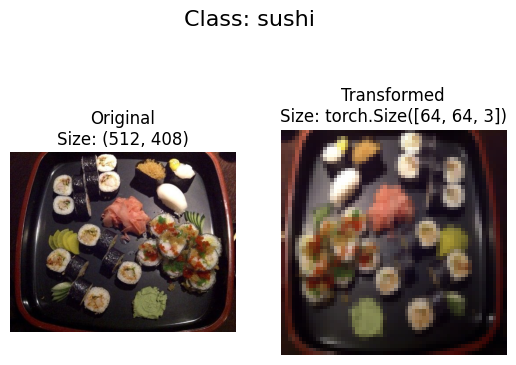

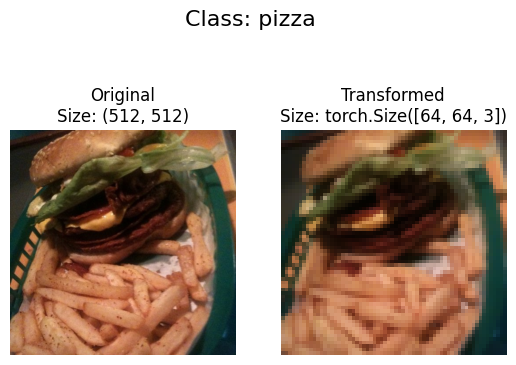

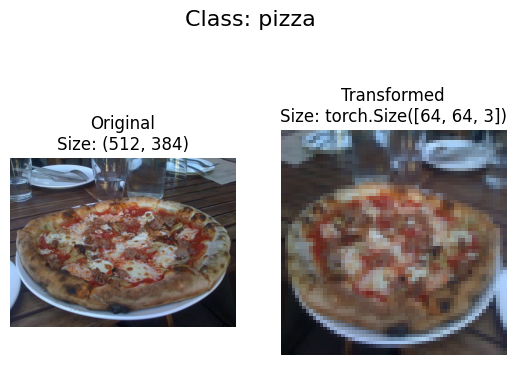

In [213]:
def plot_transformed_images(image_paths, transform, n=3, seed=42):
    """
    Selects random images from a path of images and loads/transforms them 
    into the original vs transformed versions
    """
    if seed:
        random.seed(seed)
    random_image_paths = random.sample(image_paths, k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(nrows=1, ncols=2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original\nSize: {f.size}")
            ax[0].axis(False)

            # Transform and plot target image
            transformed_image = transform(f).permute(1,2,0) # note: we will need to change shape for matplotlib
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed\nSize: {transformed_image.shape}")
            ax[1].axis("off")
            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)
plot_transformed_images(image_paths=image_path_list,
                        transform=data_transform,
                        n=3,
                        seed=42)

## 4. Option 1: Loading image data using `ImageFolder`

We can load image classification data using `torchvision.data.sets.ImageFolder`

In [214]:
# Use ImageFolder to create dataset(s)
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir,
                                  transform=data_transform, # a transform for the data
                                  target_transform=None) # a transform for the label/target

test_data = datasets.ImageFolder(root=test_dir,
                                 transform=data_transform)

train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data\pizza_steak_sushi\train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data\pizza_steak_sushi\test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [215]:
# Get class names as list
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [216]:
# Get class names as dictionary
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [217]:
# Check the lengths of our dataset
len(train_data), len(test_data)

(225, 75)

In [218]:
# Index on the train_data Datset ot get a single image and label
img, label = train_data[0][0], train_data[0][1]
print(f"Image tensor:\n {img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Label datatype: {type(label)}")

Image tensor:
 tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
         [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
         [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
         ...,
         [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
         [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
         [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],

        [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
         [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
         [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
         ...,
         [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
         [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
         [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],

        [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
         [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
         [0.0196, 0.0157, 0.0157,  ..., 0.0

Original shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Permuted shape: torch.Size([64, 64, 3]) -> [height, width, color_channels]


Text(0.5, 1.0, 'pizza')

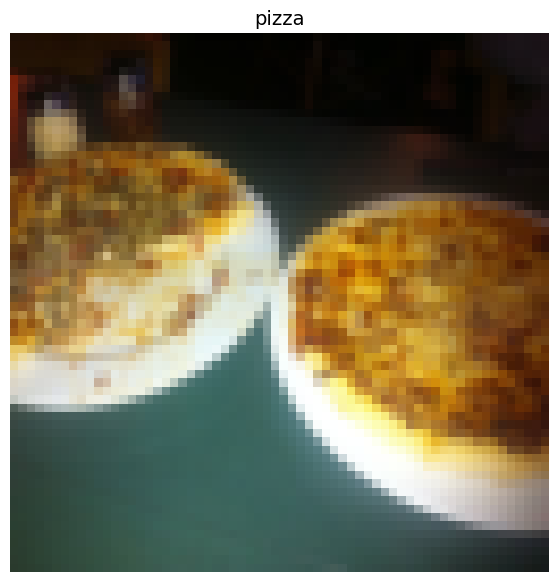

In [219]:
# Rearrange the order of dimensions
img_permute= img.permute(1,2,0)

# Print out different shapes
print(f"Original shape: {img.shape} -> [color_channels, height, width]")
print(f"Permuted shape: {img_permute.shape} -> [height, width, color_channels]")

# Plot the image
plt.figure(figsize=(10,7))
plt.imshow(img_permute)
plt.axis("off")
plt.title(class_names[label], fontsize=14)

## 4.1 Turn loaded images into `DataLoader`s

A `DataLoader` is going to help us turn our `Dataset` into iterables and we can customize the `batch_size` so our model can see `batch_size` images at a time

In [220]:
import os
os.cpu_count()

8

In [221]:
# Turn train and test datasets into DataLoaders
from torch.utils.data import DataLoader
BATCH_SIZE = 1
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              num_workers=os.cpu_count(),
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             num_workers=os.cpu_count(),
                             shuffle=False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x24f98271850>,
 <torch.utils.data.dataloader.DataLoader at 0x24fa0c83950>)

In [222]:
len(train_dataloader), len(test_dataloader)

(225, 75)

In [223]:
img, label = next(iter(train_dataloader))

# Batch size will now be 1, you can change the batch size if you like
print(f"Image shape: {img.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([1, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([1])


## 5. Option 2: Loading Image Data with a Custom `Dataset`

1. be able to load images from file
2. Be able to get class names from the Dataset 
3. Be able to get classes as dictionary from the Dataset

Pros:
* Can create a `Dataset` out of almost anything
* Not limited to PyTorch pre-built `Dataset` functions

Cons:
* Even though you could create `Dataset` out of almost anything, it doesn't mean it will work...
* Using a custom `Dataset` often results in writing more code, which could be prone to errors or performance issues

All custom datasets in PyTorch often subclass - https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset

In [224]:
import os
import pathlib
import torch

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, Dict, List

In [225]:
# Instance of torchvision.datasets.ImageFolder()
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.1 Creating a helper function to get class names

We want a function to:
1. Get the class names using `os.scandir()` to traverse a target directory (ideally the directory is in standard image classification format)
2. Raise an error if the class names aren't found (if this happens, there might be something wrong with the directory structure)
3. Turn the class names into a dict and list and return them

In [226]:
# Setup path for target directory
target_directory = train_dir
print(f"Target dir: {target_directory}")

# Get the class anmes from the target directory
class_names_found = sorted([entry.name for entry in list(os.scandir(target_directory))])
class_names_found

Target dir: data\pizza_steak_sushi\train


['pizza', 'steak', 'sushi']

In [227]:
def find_classes(directory: str) -> Tuple[List[str], Dict[str,int]]:
    """FInds the class folder names in a target directory."""
    # 1. Get the class names by scanning the target directory
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())

    # 2. Raise an error if class anmes could not be found
    if not classes:
        raise FileNotFoundError(f"Couldn't find any classes in {directory}... please check file structure")
    
    # 3. Create a dictionary of index labels (computers prefer numbers rather than strings as labels)
    class_to_idx = {class_name: i for i, class_name in enumerate(classes)}
    return classes, class_to_idx

In [228]:
find_classes(target_directory)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.2 Create a custom `Dataset` to replicate `ImageFolder`

To create our own custom dataset, we want to:

1. Subclass `torch.utils.data.Dataset`
2. Init our subclass with a target directory (the directory we'd like to get data from) as well as a transform if we'd like to transform our data
3. Create several attributes:
    * paths - paths of our images
    * transform - the transform we'd like to use
    * classes - a list of the target classes
    * class_to_idx - a dict of the target classes mapped to integer labels
4. Create a function to `load_images()`, thus function will open an image
5. Overwrite the `__len__()` method to return the length of our dataset
6. Overwrite the `__getitem__()` method to return a given sample when passed an index

In [229]:
# 0. Write a custom dataset class
from torch.utils.data import Dataset

# 1. Subclass torch.utils.data.Dataset
class ImageFolderCustom(Dataset):
    # 2. Intialize our custom dataset
    def __init__(self, 
                 targ_dir: str, 
                 transform=None):
        # 3. Create class attributes
        # Get all of the image paths
        self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg"))
        # Setup transforms
        self.transforms = transform
        # Create classes and class_to_idx attributes
        self.classes, self.class_to_idx = find_classes(targ_dir)
    
    # 4. Create a function to load iamges
    def load_image(self, index: int) -> Image.Image:
        "Opens an image via a path and returns it"
        image_path = self.paths[index]
        return Image.open(image_path)

    # 5. Overwrite __len__()
    def __len__(self) -> int:
        "Returns the total number of samples"
        return len(self.paths)
    
    # 6. Overwrite __getitem()__ to return a particular sample
    def __getitem__(self, index:int) -> Tuple[torch.Tensor, int]:
        "Returns one sample of data, data and label (X,y)"
        img = self.load_image(index)
        class_name = self.paths[index].parent.name # expects path in format: data_folder/class_name/image.jpg
        class_idx = self.class_to_idx[class_name]

        # Transform if necessary
        if self.transforms:
            return self.transforms(img), class_idx # return data, label (X,y)
        else:
            return img, class_idx # Return img, label

In [230]:
# Create a transform
from torchvision import transforms
train_transforms = transforms.Compose([
                                        transforms.Resize(size=(64,64)),
                                        transforms.RandomHorizontalFlip(p=0.5),
                                        transforms.ToTensor()
])

test_transforms = transforms.Compose([
                                        transforms.Resize(size=(64,64)),
                                        transforms.ToTensor()
])

In [231]:
# Test out ImageFolderCustom
train_data_custom = ImageFolderCustom(targ_dir = train_dir,
                                      transform = train_transforms)

test_data_custom = ImageFolderCustom(targ_dir = test_dir,
                                     transform=test_transforms)

In [232]:
train_data_custom, test_data_custom

(<__main__.ImageFolderCustom at 0x24f983ad6a0>,
 <__main__.ImageFolderCustom at 0x24f9a1be850>)

In [233]:
len(train_data), len(train_data_custom)

(225, 225)

In [234]:
len(test_data), len(test_data_custom)

(75, 75)

In [235]:
train_data_custom.classes

['pizza', 'steak', 'sushi']

In [236]:
train_data_custom.class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [237]:
# Check for equality between original ImageFolder Dataset and ImageFolderCustomDataset
print(train_data_custom.classes == train_data.classes)
print(test_data_custom.classes == test_data_custom.classes)

True
True


### 5.3 Create a function to display random images

1. Take in a `Dataset` and a number of other parameters such as class names and how many iamges to visualize
2. To prevent the display getting out of hand, let's cap the number of images to 10
3. Set the random seed for reproducibility
4. Get a list of random saple indexes from the target dataset
5. Setup a matplotlib plot
6. Loop through the random sample images and plot them with matplotlib
7. Make sure dimensions of our images line up with matplotlib (HWC)

In [238]:
# 1. Create a function to take in a dataset
def display_random_images(dataset: torch.utils.data.Dataset,
                          classes: List[str] = None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int = None):
    # 2. Adjust display if n is too high
    if n > 10:
        n = 10
        display_shape = False
        print(f"For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display")

    # 3. Set the seed
    if seed:
        random.seed(seed)
    
    # 4. get random sample indexes
    random_samples_idx = random.sample(range(len(dataset)), k=n)

    # 5. Setuip plot
    plt.figure(figsize=(16,8))

    # 6. Loop through indexs + plot with matplotlib
    for i, targ_sample in enumerate(random_samples_idx):
        targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]

        # 7. Adjust tensor dimension 4 plotting
        targ_image_adjust = targ_image.permute(1,2,0) # color, height, width -> height, width, color

        # Plot adjusted samples
        plt.subplot(1, n, i+1)
        plt.imshow(targ_image_adjust)
        plt.axis("off")
        if classes:
            title = f"Class: {classes[targ_label]}"
            if display_shape:
                title = title + f"\nshape: {targ_image_adjust.shape}"
        plt.title(title)


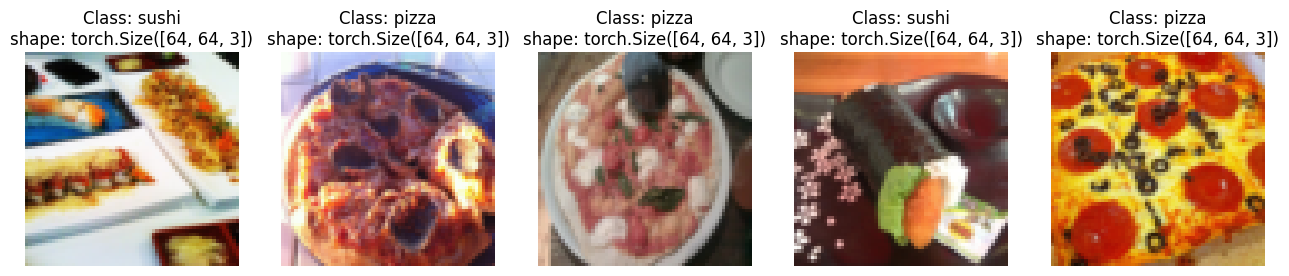

In [239]:
# Display random images from ImageFolder dataset
display_random_images(train_data,
                      classes=class_names,
                      n=5,
                      seed=42)

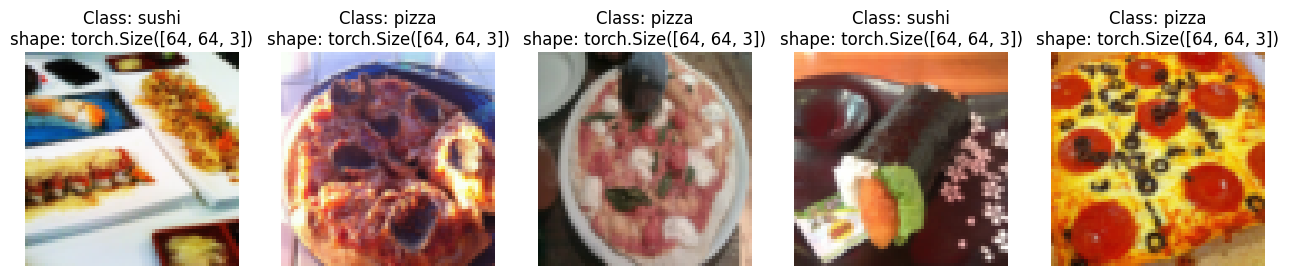

In [240]:
# Display random images from ImageFolderCustom dataset
display_random_images(train_data_custom,
                      classes=class_names,
                      n=5,
                      seed=42)

### 5.4 Turn custom loaded images into DataLoaders

In [241]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32
train_dataloader_custom = DataLoader(dataset=train_data_custom,
                              batch_size=BATCH_SIZE,
                              shuffle=True)

test_dataloader_custom = DataLoader(dataset=test_data_custom,
                                    batch_size=BATCH_SIZE,
                                    shuffle=False)

train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x24fa0d88850>,
 <torch.utils.data.dataloader.DataLoader at 0x24fa0d88b50>)

In [242]:
# Get image and label from custom dataloader
img_custom, label_custom = next(iter(train_dataloader_custom))
# Print out the shapes
img_custom.shape, label_custom.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

## 6. Other forms of transforms (data augmentation)

Data augmentation is the process of artificially adding diversity to your training data

In the case of image data, this may mean applying various image transformations to the training data

This practice hopefully results in a model that's more generalizable to unseen data

Let's look at one particular type of data augmentation used to train PyTorch vision models to state of the art levels...



In [243]:
# Let's look at trivialaugment
from torchvision import transforms

train_transform = transforms.Compose([
                                        transforms.Resize(size=(224,224)),
                                        transforms.TrivialAugmentWide(num_magnitude_bins=31),
                                        transforms.ToTensor()
])

test_transform = transforms.Compose([
                                    transforms.Resize(size=(224,224)),
                                    transforms.ToTensor()
])

In [244]:
image_path

WindowsPath('data/pizza_steak_sushi')

In [245]:
# Get all image paths
image_path_list = list(image_path.glob("*/*/*.jpg"))
image_path_list[:10]

[WindowsPath('data/pizza_steak_sushi/test/pizza/1152100.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/1503858.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/1687143.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/1925494.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/194643.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/195160.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2003290.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2019408.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2111981.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2124579.jpg')]

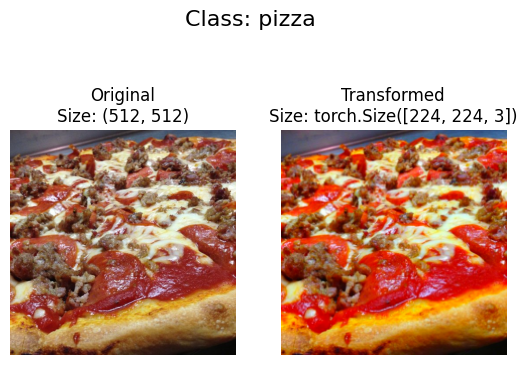

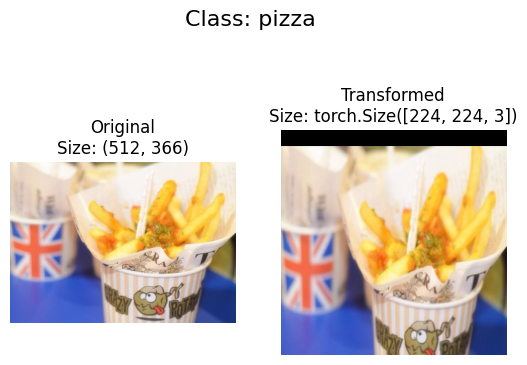

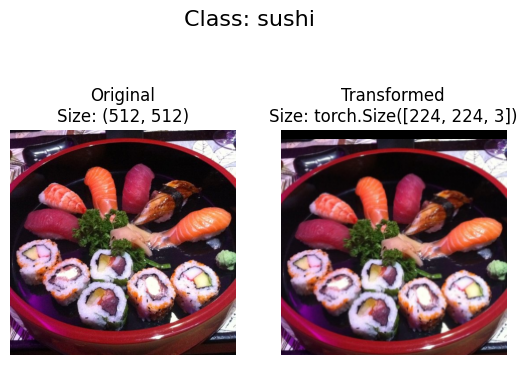

In [246]:
# Plot random transformed images
plot_transformed_images(
    image_paths=image_path_list,
    transform=train_transform,
    n=3,
    seed=None
)

## 7. Model 0: TinyVGG without data augmentation

Let's replicate the TinyVGG architecture

### 7.1 Creating transforms and loading data for Model 0

In [247]:
# Create simple transform
simple_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])

In [248]:
# 1. Load and transform data
from torchvision import datasets
train_data_simple = datasets.ImageFolder(root=train_dir,
                                         transform=simple_transform)
test_data_simple = datasets.ImageFolder(root=test_dir,
                                        transform=simple_transform)

# 2. Turn the datasets into DataLoaders
import os
from torch.utils.data import DataLoader

# Setup batch size and number of workers
BATCH_SIZE = 32
#NUM_WORKERS = os.cpu_count()

# Create DataLoader's
train_dataloader_simple = DataLoader(dataset=train_data_simple,
                                     batch_size=BATCH_SIZE,
                                     shuffle=True,
                                     num_workers=0 # NUM_WORKERS
                                     )
test_dataloader_simple = DataLoader(dataset=test_data_simple,
                                    batch_size=BATCH_SIZE,
                                    shuffle=False,
                                    num_workers= 0)

### 7.2 Create TinyVGG model class

In [ ]:
import torch.nn as nn
class TinyVGG(nn.Module):
    """
    Model architecture copying TinyVGG from CNN Explainer
    """
    def __init__(self, input_shape: int,
                 hidden_units: int,
                 output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1
                      ),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1
                      ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # default stride value is same as kernel_size
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1
                      ),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1
                      ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # default stride value is same as kernel_size
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units * 16*16,
                      out_features=output_shape)
        )
    
    def forward(self, x):
        x = self.conv_block_1(x)
        #print(x.shape)
        x = self.conv_block_2(x)
        #print(x.shape)
        x = self.classifier(x)
        #print(x.shape)
        return x
        # return self.classifier(self.conv_block_2(self.conv_block_1(x))) benefits from operator fusion

In [250]:
torch.manual_seed(42)
model_0 = TinyVGG(input_shape = 3, # of color channels in our image data
                  hidden_units=32,
                  output_shape=len(class_names))
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=3, bias=True)
  )
)

### 7.3 Try a forward pass on a single image (to test the model)

In [251]:
# Get a single image batch
image_batch, label_batch = next(iter(train_dataloader_simple))
image_batch.shape, label_batch.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [252]:
# Try a forward pass
model_0(image_batch)

tensor([[ 0.0079,  0.0172,  0.0029],
        [ 0.0064,  0.0177,  0.0044],
        [ 0.0080,  0.0200, -0.0002],
        [ 0.0052,  0.0186,  0.0026],
        [ 0.0069,  0.0186,  0.0064],
        [ 0.0052,  0.0187,  0.0040],
        [ 0.0076,  0.0205,  0.0007],
        [ 0.0072,  0.0201,  0.0033],
        [ 0.0077,  0.0210,  0.0047],
        [ 0.0065,  0.0121,  0.0018],
        [ 0.0068,  0.0169,  0.0025],
        [ 0.0067,  0.0184,  0.0015],
        [ 0.0084,  0.0211,  0.0027],
        [ 0.0045,  0.0182,  0.0024],
        [ 0.0102,  0.0208,  0.0021],
        [ 0.0057,  0.0146,  0.0023],
        [ 0.0070,  0.0171,  0.0028],
        [ 0.0046,  0.0192,  0.0036],
        [ 0.0061,  0.0190,  0.0021],
        [ 0.0068,  0.0176,  0.0034],
        [ 0.0064,  0.0171,  0.0045],
        [ 0.0051,  0.0200,  0.0031],
        [ 0.0062,  0.0184,  0.0026],
        [ 0.0062,  0.0182,  0.0037],
        [ 0.0097,  0.0186,  0.0055],
        [ 0.0080,  0.0165,  0.0025],
        [ 0.0051,  0.0175,  0.0034],
 

### 7.4 Use `torchinfo` to get an idea of the shapes going through our model

In [253]:
from torchinfo import summary
summary(model=model_0,input_size=(1,3,64,64))

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 32, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 32, 64, 64]           896
│    └─ReLU: 2-2                         [1, 32, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 32, 64, 64]           9,248
│    └─ReLU: 2-4                         [1, 32, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 32, 32, 32]           --
├─Sequential: 1-2                        [1, 32, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 32, 32, 32]           9,248
│    └─ReLU: 2-7                         [1, 32, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 32, 32, 32]           9,248
│    └─ReLU: 2-9                         [1, 32, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 32, 16, 16]           --
├─Seq

## 7.5 Create train and test loop functions

* `train_step()` - takes in a model and dataloader and trains the model on the dataloader
* `test_step()` - takes in a model and dataloader and evaluates the model on the dataloader

In [254]:
# Create train_step()
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):
    # Put the model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0,0

    # Loop through dataloader via batches
    for batch, (X,y) in enumerate(dataloader):
        # Send data to the target device
        # X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X) # output model logits

        # 2. Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate accuracy + accumulate it
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class==y).sum().item()/len(y_pred)
    # Adjust metrics to get avg loss + acc per batch
    train_loss = train_loss/len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):
    # Put model in eval mode
    model.eval()

    # Setup test loss and acc
    test_loss, test_acc = 0,0

    # Turn on inference mode
    with torch.inference_mode():

        # Loop through dataloader
        for batch, (X,y) in enumerate(dataloader):
            # Send data to target device
            # X,y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred_logits=model(X) # raw logits
            
            # 2. Calculate the loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate the accuracy
            test_pred_labels = torch.argmax(torch.softmax(test_pred_logits, dim=1),dim=1)
            test_acc += (test_pred_labels == y).sum().item()/len(test_pred_labels)

    # Adjust metrics to get avg loss & acc
    test_loss = test_loss/len(dataloader)
    test_acc = test_acc/len(dataloader)
    return test_loss, test_acc

### 7.6 Creating a `train()` function to combine `train_step()` and `test_step()`

In [255]:
# 1. Create a train function that takes in various model parameters + optimizer + dataloaders + loss function
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):
    
    # 2. Create empty results dictionary
    results = {"train_loss": [],
               "train_acc": [],
               "test_loss": [],
               "test_acc": []}
    
    # 3. Loop through training and testing steps for a number of epochs
    for epoch in range(epochs):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)
        test_loss, test_acc = test_step(model=model,
                                        dataloader=test_dataloader,
                                        loss_fn=loss_fn)
        # 4. Print out what's happening
        print(f"Epoch: {epoch} | Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

        # 5. Update results dictionary
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

    # 6. Return filled results at end of epochs
    return results

### 7.7 Train and evaluate model 0

In [256]:
# Set random seeds
torch.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 40

#  Recreate instance of TinyVGG
model_0 = TinyVGG(input_shape=3, # number color channels
                  hidden_units=16,
                  output_shape=len(train_data.classes))

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(),
                             lr=0.0001)

# Train model_0
model_0_results = train(model=model_0,
                        train_dataloader=train_dataloader_simple,
                        test_dataloader=test_dataloader_simple,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)

Epoch: 0 | Train loss: 1.1071 | Train acc: 0.2773 | Test loss: 1.1134 | Test acc: 0.2604
Epoch: 1 | Train loss: 1.0965 | Train acc: 0.3633 | Test loss: 1.1030 | Test acc: 0.1979
Epoch: 2 | Train loss: 1.0998 | Train acc: 0.2930 | Test loss: 1.1021 | Test acc: 0.1979
Epoch: 3 | Train loss: 1.0960 | Train acc: 0.4180 | Test loss: 1.0963 | Test acc: 0.2585
Epoch: 4 | Train loss: 1.0979 | Train acc: 0.2930 | Test loss: 1.0973 | Test acc: 0.1979
Epoch: 5 | Train loss: 1.1051 | Train acc: 0.3125 | Test loss: 1.0933 | Test acc: 0.3712
Epoch: 6 | Train loss: 1.0997 | Train acc: 0.3984 | Test loss: 1.0959 | Test acc: 0.5038
Epoch: 7 | Train loss: 1.0930 | Train acc: 0.5039 | Test loss: 1.1013 | Test acc: 0.2604
Epoch: 8 | Train loss: 1.0873 | Train acc: 0.4258 | Test loss: 1.1063 | Test acc: 0.2604
Epoch: 9 | Train loss: 1.1048 | Train acc: 0.3047 | Test loss: 1.1128 | Test acc: 0.2604
Epoch: 10 | Train loss: 1.1052 | Train acc: 0.3047 | Test loss: 1.1036 | Test acc: 0.2604
Epoch: 11 | Train lo

In [257]:
model_0_results

{'train_loss': [1.1070822179317474,
  1.0965411365032196,
  1.0997704416513443,
  1.0959876477718353,
  1.097903236746788,
  1.105056643486023,
  1.0996956378221512,
  1.0930386632680893,
  1.0873062312602997,
  1.1048116236925125,
  1.1051962971687317,
  1.0971426218748093,
  1.0882921069860458,
  1.0824360698461533,
  1.0759853571653366,
  1.0952234417200089,
  1.0877489894628525,
  1.0632934123277664,
  1.047325536608696,
  1.049917384982109,
  1.0968407541513443,
  0.9870641604065895,
  1.0281110927462578,
  1.0187721103429794,
  0.9312261193990707,
  0.9510902687907219,
  1.0623424276709557,
  0.9068723693490028,
  0.9588797986507416,
  0.9637382328510284,
  0.8753319978713989,
  0.827896349132061,
  0.9133684113621712,
  0.9034586921334267,
  0.812780100852251,
  0.889876015484333,
  0.9360877126455307,
  0.8543603792786598,
  0.7460919329896569,
  0.9252363219857216],
 'train_acc': [0.27734375,
  0.36328125,
  0.29296875,
  0.41796875,
  0.29296875,
  0.3125,
  0.3984375,
  0.50

### 7.8 Plot the loss curves of model_0

A **loss curve** is a way of tracking your model's progress over time

In [258]:
# Get the model_0_results keys
model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

In [259]:
def plot_loss_curves(results: Dict[str, List[float]]):
    """Plots training curves of a results dictionary"""
    # Get loss values of results dictionary(training and test)
    train_loss = results["train_loss"]
    test_loss = results["test_loss"]

    # Get accuracy values of results dictionary(training and test)
    train_acc = results["train_acc"]
    test_acc = results["test_acc"]

    # Figure out how many epochs there were
    epochs = range(len(results["train_loss"]))
    
    # Setup a plot
    plt.figure(figsize=(15,7))

    # Plot the loss
    plt.subplot(1,2,1)
    plt.plot(epochs, train_loss, label="train_loss")
    plt.plot(epochs, test_loss, label="test_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    # Plot the accuracy
    plt.subplot(1,2,2)
    plt.plot(epochs, train_acc, label="train_acc")
    plt.plot(epochs, test_acc, label="test_acc")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

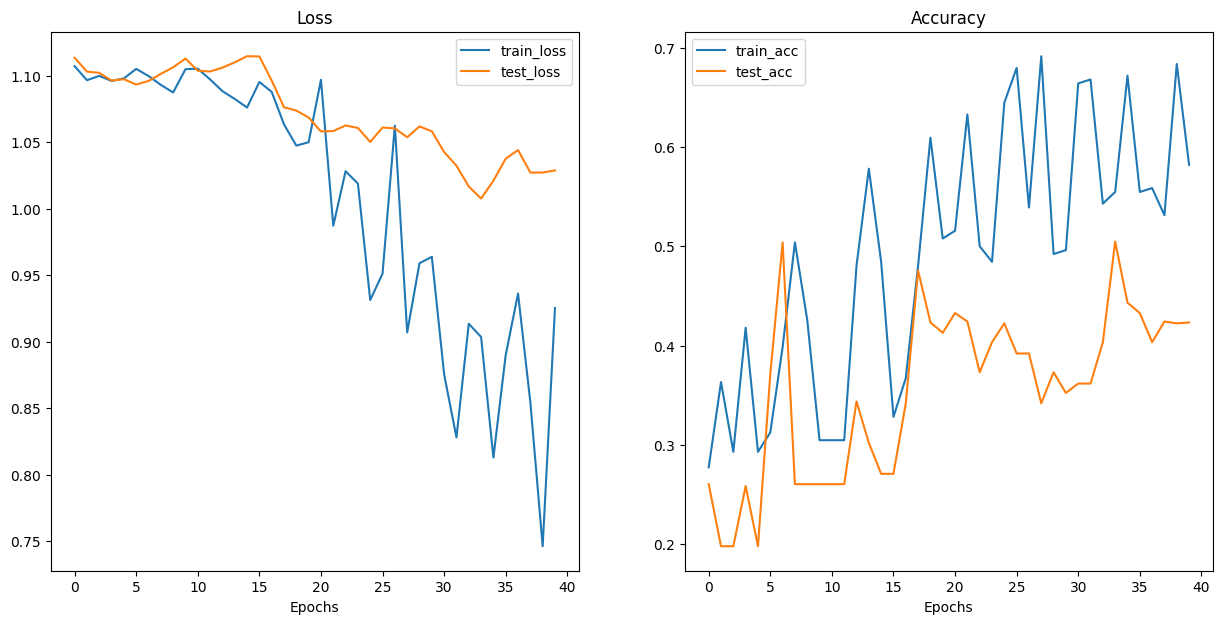

In [260]:
plot_loss_curves(model_0_results)

## 8. What should an ideal loss curve look like?

A loss curve is one of the most helpful ways to troubleshoot a model.

## 9. Model 1: TinyVGG with Data Augmentation

Now let's try another modelling experiment this time using the same model as before but with some slight data augmentation

### 9.1 Create transform with data augmentation

In [261]:
# Create training transform with TrivialAugment
from torchvision import transforms
train_transform_trivial = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

test_transform_simple = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])

### 9.2 Create train and test `Dataset`'s and `DataLoader`'s with data augmentation

In [262]:
# Turn image folders into Datasets
from torchvision import datasets
train_data_augmented = datasets.ImageFolder(root=train_dir,
                                              transform=train_transform_trivial)
test_data_simple = datasets.ImageFolder(root=test_dir,
                                        transform=test_transform_simple)

In [263]:
# Turn datasets into dataloaders
# import os
from torch.utils.data import DataLoader
BATCH_SIZE = 32
# NUM_WORKERS = os.cpu_count()

torch.manual_seed(42)
train_dataloader_augmented = DataLoader(dataset=train_data_augmented,
                                        batch_size=BATCH_SIZE,
                                        shuffle=True)
test_dataloader_simple = DataLoader(dataset=test_data_simple,
                                    batch_size=BATCH_SIZE,
                                    shuffle=False)

### 9.3 Construct and train model 1

This time we'll be using the same model architecture except this time we've augmented the training data

In [267]:
# Create model_1
torch.manual_seed(42)
model_1 = TinyVGG(input_shape=3,
                  hidden_units=16,
                  output_shape=len(train_data_augmented.classes))
model_1

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=3, bias=True)
  )
)

Now we've got a model and dataloaders, let's create a loss function and optimizer and call our `train()` function to train + evaluate the model

In [268]:
# Set random seeds
torch.manual_seed(42)

# Set epochs
NUM_EPOCHS = 20

# Setup loss function
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(),
                             lr=0.001)

# Train model 1
model_1_results = train(model=model_1,
                        train_dataloader=train_dataloader_augmented,
                        test_dataloader=test_dataloader_simple,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS
                        )

Epoch: 0 | Train loss: 1.1077 | Train acc: 0.3086 | Test loss: 1.1077 | Test acc: 0.2604
Epoch: 1 | Train loss: 1.0805 | Train acc: 0.4258 | Test loss: 1.1377 | Test acc: 0.2604
Epoch: 2 | Train loss: 1.1252 | Train acc: 0.3047 | Test loss: 1.1304 | Test acc: 0.2604
Epoch: 3 | Train loss: 1.1126 | Train acc: 0.3711 | Test loss: 1.0736 | Test acc: 0.5625
Epoch: 4 | Train loss: 1.0896 | Train acc: 0.3438 | Test loss: 1.0965 | Test acc: 0.2604
Epoch: 5 | Train loss: 1.0568 | Train acc: 0.4805 | Test loss: 1.0698 | Test acc: 0.3523
Epoch: 6 | Train loss: 1.0447 | Train acc: 0.4805 | Test loss: 1.0741 | Test acc: 0.3324
Epoch: 7 | Train loss: 0.9824 | Train acc: 0.5195 | Test loss: 1.0844 | Test acc: 0.3741
Epoch: 8 | Train loss: 0.9552 | Train acc: 0.5469 | Test loss: 1.0687 | Test acc: 0.3210
Epoch: 9 | Train loss: 0.9510 | Train acc: 0.5977 | Test loss: 1.0858 | Test acc: 0.3636
Epoch: 10 | Train loss: 1.0173 | Train acc: 0.4180 | Test loss: 1.0444 | Test acc: 0.3712
Epoch: 11 | Train lo

### 9.4 Plot the loss curves of model 1
A loss curve helps youe valuate your models performance overtime

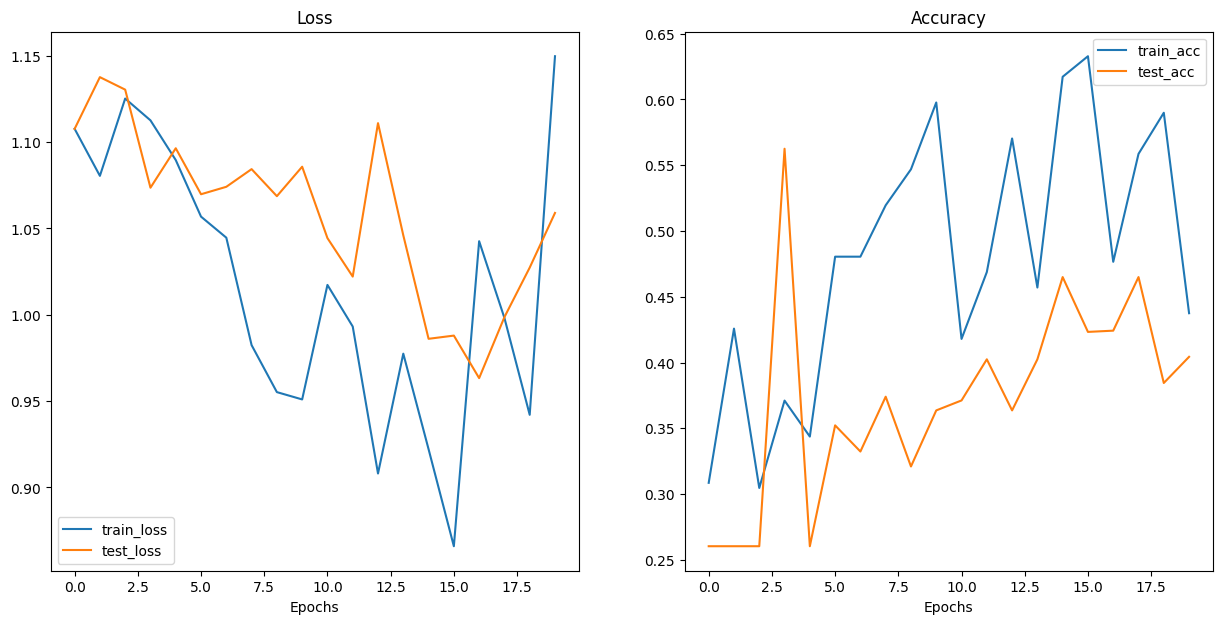

In [269]:
plot_loss_curves(model_1_results)

## 10. Compare model results

After evaluating our modelling experiments on their own, it's important to compare them to each other.

There's a few different ways to do this:
1. Hard coding (what we're doing)
2. PyTorch + Tensorboard - https://pytorch.org/docs/stable/tensorboard.html
3. Weights & Biases - https://wandb.ai/site/experiment-tracking
4. MLFlow - https://mlflow.org/

In [272]:
import pandas as pd
model_0_df = pd.DataFrame(model_0_results)
model_1_df = pd.DataFrame(model_1_results)
model_0_df[:5]

,train_loss,train_acc,test_loss,test_acc
0,1.107082,0.277344,1.113448,0.260417
1,1.096541,0.363281,1.102970,0.197917
2,1.099770,0.292969,1.102063,0.197917
3,1.095988,0.417969,1.096303,0.258523
4,1.097903,0.292969,1.097273,0.197917


In [ ]:
# 